# Decision Trees - Chapter 6
# Training, Visualizing, Regularization, and Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, make_moons
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_graphviz
from graphviz import Source

In [2]:
iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

print("Model trained successfully.")
print("Classes:", iris.target_names)

Model trained successfully.
Classes: ['setosa' 'versicolor' 'virginica']


In [3]:
export_graphviz(
    tree_clf,
    out_file="iris_tree.dot",
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

print("iris_tree.dot saved.")

iris_tree.dot saved.


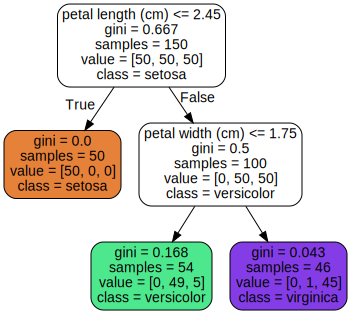

In [4]:
Source.from_file("iris_tree.dot")

In [6]:
print(tree_clf.predict_proba([[5, 1.5]]).round(3))
print(tree_clf.predict([[5, 1.5]]))

[[0.    0.907 0.093]]
[1]


In [7]:
def plot_decision_boundary(clf, X, y, axes, title):
    x1s = np.linspace(axes[0], axes[1], 500)
    x2s = np.linspace(axes[2], axes[3], 500)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.figure(figsize=(10, 6))
    plt.contourf(x1, x2, y_pred, alpha=0.3)
    plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], "yo", label="Iris setosa")
    plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], "bs", label="Iris versicolor")
    plt.plot(X[:, 0][y == 2], X[:, 1][y == 2], "g^", label="Iris virginica")
    plt.xlabel("Petal length (cm)")
    plt.ylabel("Petal width (cm)")
    plt.legend()
    plt.title(title)
    plt.show()

#Plot iris decision boundary

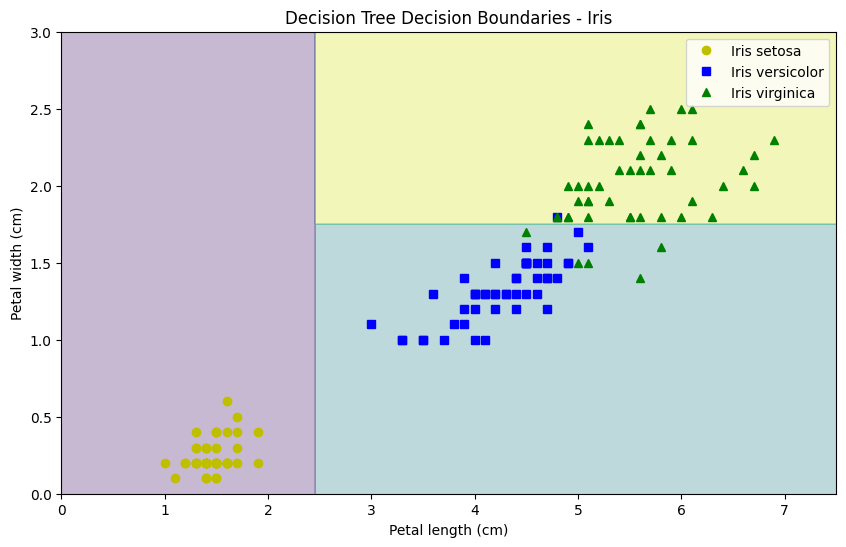

In [8]:
plot_decision_boundary(
    tree_clf,
    X_iris,
    y_iris,
    [0, 7.5, 0, 3],
    "Decision Tree Decision Boundaries - Iris"
)

#Train the moons models

In [9]:
X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=42)

tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)

DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

In [10]:
def plot_boundary(clf, X, y, title):
    x1s = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 500)
    x2s = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 500)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3)
    plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], "ko")
    plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], "^", color="brown")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)

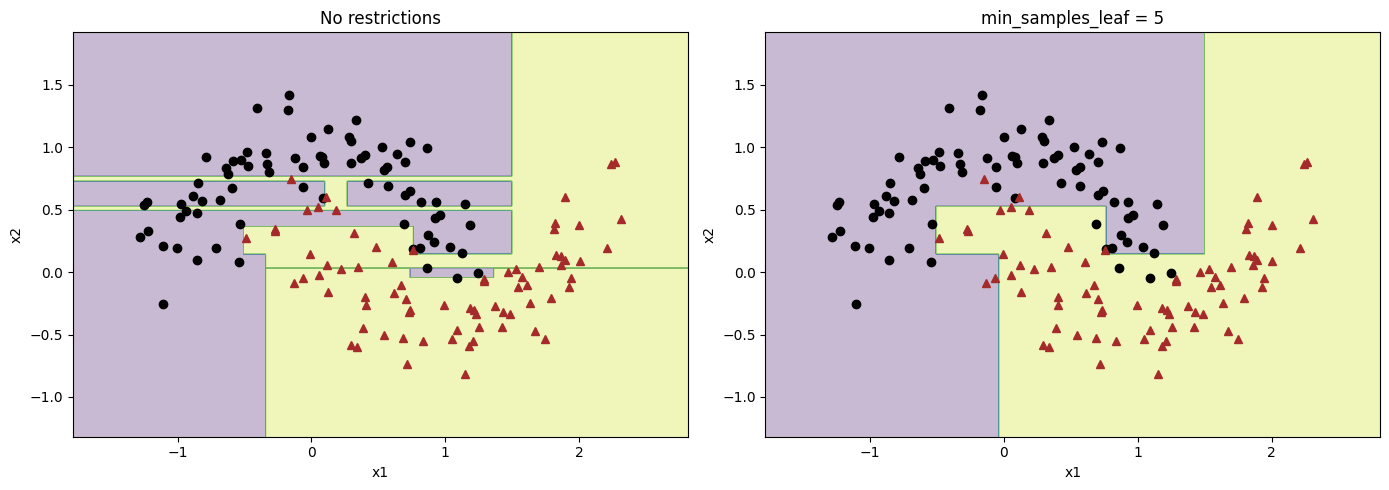

In [11]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plot_boundary(tree_clf1, X_moons, y_moons, "No restrictions")

plt.subplot(1, 2, 2)
plot_boundary(tree_clf2, X_moons, y_moons, "min_samples_leaf = 5")

plt.tight_layout()
plt.savefig("decision_tree_moons.png", dpi=300, bbox_inches="tight")
plt.show()

#Test Accuracy

In [12]:
X_moons_test, y_moons_test = make_moons(n_samples=1000, noise=0.2, random_state=43)

print("Unregularized tree accuracy:", tree_clf1.score(X_moons_test, y_moons_test))
print("Regularized tree accuracy:", tree_clf2.score(X_moons_test, y_moons_test))

Unregularized tree accuracy: 0.898
Regularized tree accuracy: 0.92


In [13]:
np.random.seed(42)
X_quad = np.random.rand(200, 1) - 0.5
y_quad = X_quad ** 2 + 0.025 * np.random.randn(200, 1)

tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_quad, y_quad)

DecisionTreeRegressor(max_depth=2, random_state=42)

#Regression Predictions

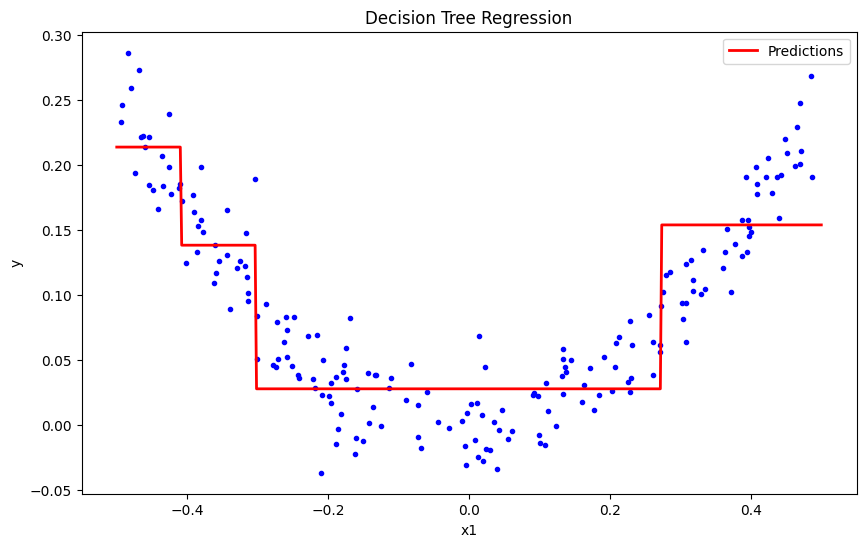

In [14]:
x_new = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)
y_pred = tree_reg.predict(x_new)

plt.figure(figsize=(10, 6))
plt.plot(X_quad, y_quad, "b.")
plt.plot(x_new, y_pred, "r-", linewidth=2, label="Predictions")
plt.xlabel("x1")
plt.ylabel("y")
plt.title("Decision Tree Regression")
plt.legend()
plt.savefig("decision_tree_regression.png", dpi=300, bbox_inches="tight")
plt.show()